# MovieLens Knowledge Graph

MovieLens 1M の変換済みデータを読み込み、属性グラフ構築に使う入力テーブルを準備する。

## Data Load

このノートでは、属性グラフの構築でそのまま扱いやすい `transformed parquet` を中心にロードする。

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import pandas as pd

from src.movielens_kg import (
    add_minmax_display_weight,
    add_transition_probabilities,
    build_attribute_nodes,
    build_graph_edge_tables,
    build_interactive_graph_figure,
    build_mixed_to_digraph,
    build_networkx_graph,
    build_structural_movie_edges,
    build_user_preference_movie_edges,
    build_user_to_movie_edges,
    draw_graph,
    extract_top_weight_subgraph,
    propagate_activation,
    trace_activation,
)


In [2]:
DATA_DIR = Path("./data")

movies_df = pd.read_parquet(DATA_DIR / "movies_transformed.parquet")
users_df = pd.read_parquet(DATA_DIR / "users_transformed.parquet")
ratings_df = pd.read_parquet(DATA_DIR / "ratings_transformed.parquet")
transaction_df = pd.read_parquet(DATA_DIR / "transaction.parquet")

In [3]:
pd.DataFrame(
    {
        "table_name": [
            "movies_transformed",
            "users_transformed",
            "ratings_transformed",
            "transaction",
        ],
        "rows": [
            len(movies_df),
            len(users_df),
            len(ratings_df),
            len(transaction_df),
        ],
        "columns": [
            movies_df.shape[1],
            users_df.shape[1],
            ratings_df.shape[1],
            transaction_df.shape[1],
        ],
    }
)

,table_name,rows,columns
0,movies_transformed,3883,33
1,users_transformed,6040,37
2,ratings_transformed,1000209,8
3,transaction,1000209,71


## Attribute Node Definition

属性グラフでは、one-hot 化された属性列名をそのまま node id として扱う。

In [4]:
user_attribute_columns = [
    column
    for column in users_df.columns
    if column.startswith(("gender_", "age_", "occupation_"))
    and column not in {"age_category", "occupation_category"}
]

movie_genre_columns = [
    column for column in movies_df.columns if column.startswith("genre_")
]

movie_decade_columns = [
    column
    for column in movies_df.columns
    if column.startswith("release_decade_") and column != "release_decade"
]

movie_attribute_columns = movie_genre_columns + movie_decade_columns

In [5]:
attribute_column_config = {
    "user_attributes": user_attribute_columns,
    "movie_genres": movie_genre_columns,
    "movie_decades": movie_decade_columns,
    "movie_attributes": movie_attribute_columns,
}

pd.DataFrame(
    [
        {"attribute_group": group, "column_name": column}
        for group, columns in attribute_column_config.items()
        for column in columns
    ]
)

,attribute_group,column_name
0,user_attributes,gender_F
1,user_attributes,gender_M
2,user_attributes,age_18_24
3,user_attributes,age_25_34
4,user_attributes,age_35_44
...,...,...
81,movie_attributes,release_decade_1960s
82,movie_attributes,release_decade_1970s
83,movie_attributes,release_decade_1980s
84,movie_attributes,release_decade_1990s


In [6]:
attribute_node_summary = pd.DataFrame(
    {
        "attribute_group": [
            "user_attributes",
            "movie_genres",
            "movie_decades",
            "movie_attributes",
        ],
        "node_count": [
            len(user_attribute_columns),
            len(movie_genre_columns),
            len(movie_decade_columns),
            len(movie_attribute_columns),
        ],
    }
)

attribute_node_summary

,attribute_group,node_count
0,user_attributes,30
1,movie_genres,18
2,movie_decades,10
3,movie_attributes,28


## User Attribute To Movie Attribute Edges

`rating >= 4` を支持イベントとみなし、user attribute と movie attribute の直積からエッジを構築する。

In [7]:
INTERACTION_COLUMN = "has_interaction"
MIN_USER_TO_MOVIE_COUNT = 30
MIN_ITEM_TO_ITEM_COUNT = 30
USER_ATTRIBUTE_SHARE_THRESHOLD = 0.20
MIN_TRANSITION_PROBABILITY = 0.20


In [8]:
interaction_transactions_df, user_to_movie_edges = build_user_to_movie_edges(
    transaction_df=transaction_df,
    user_attribute_columns=user_attribute_columns,
    movie_attribute_columns=movie_attribute_columns,
    positive_interaction_column=INTERACTION_COLUMN,
)

movie_structural_edges = build_structural_movie_edges(
    movies_df=movies_df,
    movie_attribute_columns=movie_attribute_columns,
)

movie_preference_genre_edges = build_user_preference_movie_edges(
    positive_transactions_df=interaction_transactions_df,
    attribute_columns=movie_genre_columns,
    edge_type="movie_to_movie_preference_genre",
    user_attribute_share_threshold=USER_ATTRIBUTE_SHARE_THRESHOLD,
)

movie_preference_decade_edges = build_user_preference_movie_edges(
    positive_transactions_df=interaction_transactions_df,
    attribute_columns=movie_decade_columns,
    edge_type="movie_to_movie_preference_decade",
    user_attribute_share_threshold=USER_ATTRIBUTE_SHARE_THRESHOLD,
)

nodes_df = build_attribute_nodes(
    user_attribute_columns=user_attribute_columns,
    movie_genre_columns=movie_genre_columns,
    movie_decade_columns=movie_decade_columns,
)

graph_edge_tables = build_graph_edge_tables(
    user_to_movie_edges=user_to_movie_edges,
    movie_structural_edges=movie_structural_edges,
    movie_preference_genre_edges=movie_preference_genre_edges,
    movie_preference_decade_edges=movie_preference_decade_edges,
    min_user_to_movie_count=MIN_USER_TO_MOVIE_COUNT,
    min_item_to_item_count=MIN_ITEM_TO_ITEM_COUNT,
)

user_movie_graph_edges = graph_edge_tables["user_movie_graph_edges"]
movie_structural_graph_edges = graph_edge_tables["movie_structural_graph_edges"]
movie_preference_genre_graph_edges = graph_edge_tables["movie_preference_genre_graph_edges"]
movie_preference_decade_graph_edges = graph_edge_tables["movie_preference_decade_graph_edges"]
movie_preference_graph_edges = graph_edge_tables["movie_preference_graph_edges"]
all_graph_edges = graph_edge_tables["all_graph_edges"]


### `user_to_movie_edges` Column Definition

| column | meaning |
| --- | --- |
| `source` | user attribute node id。例: `gender_M`, `age_25_34`, `occupation_programmer` |
| `target` | movie attribute node id。例: `genre_Sci-Fi`, `release_decade_1990s` |
| `positive_event_count` | `rating >= 4` の支持イベントから集計した、`source -> target` の生起回数 |
| `source_total_positive_events` | ある `source` から出る全 `positive_event_count` の合計 |
| `target_total_positive_events` | ある `target` に入る全 `positive_event_count` の合計 |
| `edge_type` | エッジ種別。この notebook では `user_to_movie` を格納する |
| `global_positive_events` | 全 `source -> target` edge event の総数 |
| `conditional_prob` | ある `source` から出る支持イベントのうち、`target` につながる割合 |
| `target_positive_rate` | 全体で見た `target` の出現率。`target_total_positive_events / global_positive_events` |
| `lift` | `conditional_prob / target_positive_rate`。全体平均に対してどれだけ強い接続かを表す |


## Movie Attribute To Movie Attribute Edges

movie attribute 同士の共起は、同一映画内の構造共起と、ユーザー支持を介した共起を分けて構築する。

### Movie Co-Occurrence Tables

| table | meaning |
| --- | --- |
| `movie_structural_edges` | 同一映画内で共起する movie attribute の組。`genre` と `release_decade` の cross-type edge も含む |
| `movie_preference_genre_edges` | 同じユーザーの positive movie のうち 20% 以上を占める genre を支持集合とした `genre <-> genre` 共起 |
| `movie_preference_decade_edges` | 同じユーザーの positive movie のうち 20% 以上を占める decade を支持集合とした `release_decade <-> release_decade` 共起 |


### `lift` And `jaccard`

- `jaccard`
  2つの属性を持つ entity の重なり具合を表す。両方を持つ entity 数を、どちらか一方でも持つ entity 数で割った値。
  値が大きいほど、2つの属性は似た範囲で一緒に現れやすい。

- `lift`
  2つの属性が独立に出ると仮定したときの期待値に対して、実際の共起がどれだけ強いかを表す。
  `1` 付近なら期待通り、`1` より大きければ期待以上に強い共起、`1` より小さければ期待より弱い共起と読む。

## Graph Tables

`networkx` に流す前段として、node table と共通 edge schema を作る。

### Graph Schema

| table | role |
| --- | --- |
| `nodes_df` | 全 node の一覧。`node_id`、`node_type`、`node_group` を持つ |
| `user_movie_graph_edges` | `user_to_movie` 用の graph edge table。`weight` は `lift` を使う |
| `movie_structural_graph_edges` | 構造共起用の graph edge table。`weight` は `lift` を使う |
| `movie_preference_graph_edges` | ユーザー支持共起用の graph edge table。genre ベースのみを含み、`weight` は `lift` を使う |
| `all_graph_edges` | 上記3種を連結した統合 edge table |


In [9]:
pd.DataFrame(
    {
        "table_name": [
            "nodes_df",
            "user_to_movie_edges",
            "movie_structural_edges",
            "movie_preference_genre_edges",
            "movie_preference_decade_edges",
            "user_movie_graph_edges",
            "movie_structural_graph_edges",
            "movie_preference_genre_graph_edges",
            "movie_preference_decade_graph_edges",
            "movie_preference_graph_edges",
            "all_graph_edges",
        ],
        "rows": [
            len(nodes_df),
            len(user_to_movie_edges),
            len(movie_structural_edges),
            len(movie_preference_genre_edges),
            len(movie_preference_decade_edges),
            len(user_movie_graph_edges),
            len(movie_structural_graph_edges),
            len(movie_preference_genre_graph_edges),
            len(movie_preference_decade_graph_edges),
            len(movie_preference_graph_edges),
            len(all_graph_edges),
        ],
    }
)


,table_name,rows
0,nodes_df,58
1,user_to_movie_edges,833
2,movie_structural_edges,272
3,movie_preference_genre_edges,138
4,movie_preference_decade_edges,22
5,user_movie_graph_edges,802
6,movie_structural_graph_edges,75
7,movie_preference_genre_graph_edges,70
8,movie_preference_decade_graph_edges,7
9,movie_preference_graph_edges,77


In [10]:
user_to_movie_edges.loc[
    user_to_movie_edges["positive_event_count"] >= MIN_USER_TO_MOVIE_COUNT
].sort_values("lift", ascending=False).head(20)


,source,target,positive_event_count,source_total_positive_events,target_total_positive_events,edge_type,global_positive_events,conditional_prob,target_positive_rate,lift
662,occupation_retired,release_decade_1940s,714,41511,64503,user_to_movie,9306072,0.017200,0.006931,2.481541
407,age_56_plus,release_decade_1950s,3184,117602,105696,user_to_movie,9306072,0.027074,0.011358,2.383780
606,occupation_retired,release_decade_1950s,1069,41511,105696,user_to_movie,9306072,0.025752,0.011358,2.267370
367,occupation_k12_student,genre_Children's,3888,74429,216558,user_to_movie,9306072,0.052238,0.023271,2.244793
520,age_56_plus,release_decade_1940s,1817,117602,64503,user_to_movie,9306072,0.015450,0.006931,2.229085
340,age_under_18,genre_Children's,4337,86031,216558,user_to_movie,9306072,0.050412,0.023271,2.166340
479,occupation_k12_student,genre_Animation,2164,74429,129879,user_to_movie,9306072,0.029075,0.013956,2.083256
460,age_under_18,genre_Animation,2449,86031,129879,user_to_movie,9306072,0.028466,0.013956,2.039676
497,occupation_k12_student,release_decade_2000s,1972,74429,123000,user_to_movie,9306072,0.026495,0.013217,2.004592
730,occupation_retired,release_decade_1930s,341,41511,38187,user_to_movie,9306072,0.008215,0.004103,2.001898


## Graph Visualization

`nodes_df` と graph edge table から `networkx` graph を作り、重み上位のサブグラフを描画する。

In [11]:
user_movie_graph = build_networkx_graph(
    nodes_df=nodes_df,
    edges_df=user_movie_graph_edges,
    directed=True,
)
movie_structural_graph = build_networkx_graph(
    nodes_df=nodes_df,
    edges_df=movie_structural_graph_edges,
    directed=False,
)
movie_preference_graph = build_networkx_graph(
    nodes_df=nodes_df,
    edges_df=movie_preference_graph_edges,
    directed=False,
)
normalized_all_graph_edges = add_minmax_display_weight(all_graph_edges)
combined_attribute_graph = build_mixed_to_digraph(
    nodes_df=nodes_df,
    edges_df=normalized_all_graph_edges,
)
combined_attribute_graph = add_transition_probabilities(combined_attribute_graph)
combined_attribute_graph = add_transition_probabilities(
    combined_attribute_graph,
    score_attr="support_score",
    score_metric_attr="support_score_metric",
    weight_output_attr="support_transition_weight",
    probability_output_attr="support_transition_prob",
)


In [12]:
user_to_movie_edges.loc[
    user_to_movie_edges["positive_event_count"] >= MIN_USER_TO_MOVIE_COUNT
].sort_values("lift", ascending=False).head(20)


,source,target,positive_event_count,source_total_positive_events,target_total_positive_events,edge_type,global_positive_events,conditional_prob,target_positive_rate,lift
662,occupation_retired,release_decade_1940s,714,41511,64503,user_to_movie,9306072,0.017200,0.006931,2.481541
407,age_56_plus,release_decade_1950s,3184,117602,105696,user_to_movie,9306072,0.027074,0.011358,2.383780
606,occupation_retired,release_decade_1950s,1069,41511,105696,user_to_movie,9306072,0.025752,0.011358,2.267370
367,occupation_k12_student,genre_Children's,3888,74429,216558,user_to_movie,9306072,0.052238,0.023271,2.244793
520,age_56_plus,release_decade_1940s,1817,117602,64503,user_to_movie,9306072,0.015450,0.006931,2.229085
340,age_under_18,genre_Children's,4337,86031,216558,user_to_movie,9306072,0.050412,0.023271,2.166340
479,occupation_k12_student,genre_Animation,2164,74429,129879,user_to_movie,9306072,0.029075,0.013956,2.083256
460,age_under_18,genre_Animation,2449,86031,129879,user_to_movie,9306072,0.028466,0.013956,2.039676
497,occupation_k12_student,release_decade_2000s,1972,74429,123000,user_to_movie,9306072,0.026495,0.013217,2.004592
730,occupation_retired,release_decade_1930s,341,41511,38187,user_to_movie,9306072,0.008215,0.004103,2.001898


In [13]:
pd.DataFrame(
    {
        "graph_name": [
            "user_movie_graph",
            "movie_structural_graph",
            "movie_preference_graph",
        ],
        "nodes": [
            user_movie_graph.number_of_nodes(),
            movie_structural_graph.number_of_nodes(),
            movie_preference_graph.number_of_nodes(),
        ],
        "edges": [
            user_movie_graph.number_of_edges(),
            movie_structural_graph.number_of_edges(),
            movie_preference_graph.number_of_edges(),
        ],
    }
)

,graph_name,nodes,edges
0,user_movie_graph,58,802
1,movie_structural_graph,58,75
2,movie_preference_graph,58,77


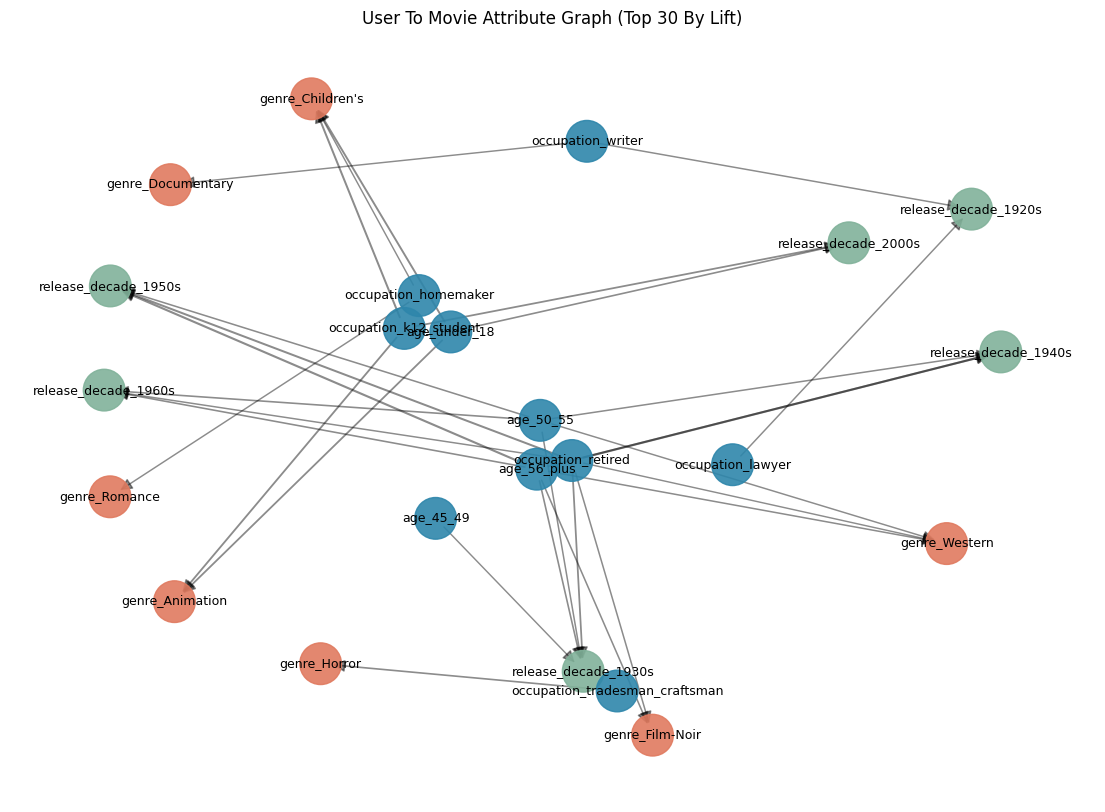

In [14]:
draw_graph(
    extract_top_weight_subgraph(user_movie_graph, top_n_edges=30),
    title="User To Movie Attribute Graph (Top 30 By Lift)",
    figsize=(14, 10),
    edge_width_scale=1.0,
)

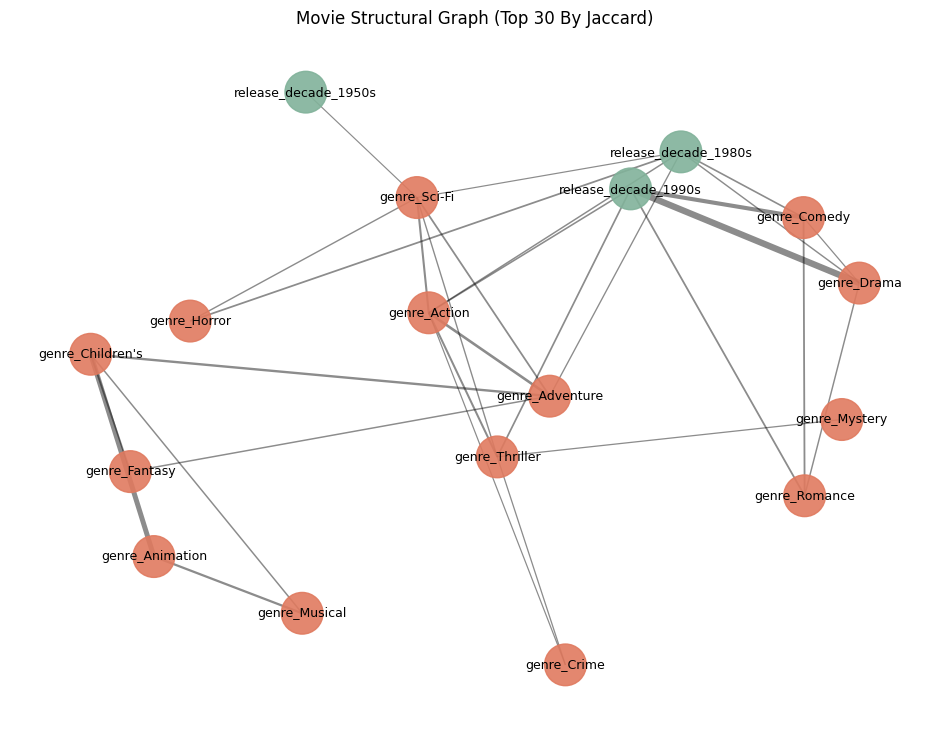

In [15]:
draw_graph(
    extract_top_weight_subgraph(movie_structural_graph, top_n_edges=30),
    title="Movie Structural Graph (Top 30 By Jaccard)",
    figsize=(12, 9),
)

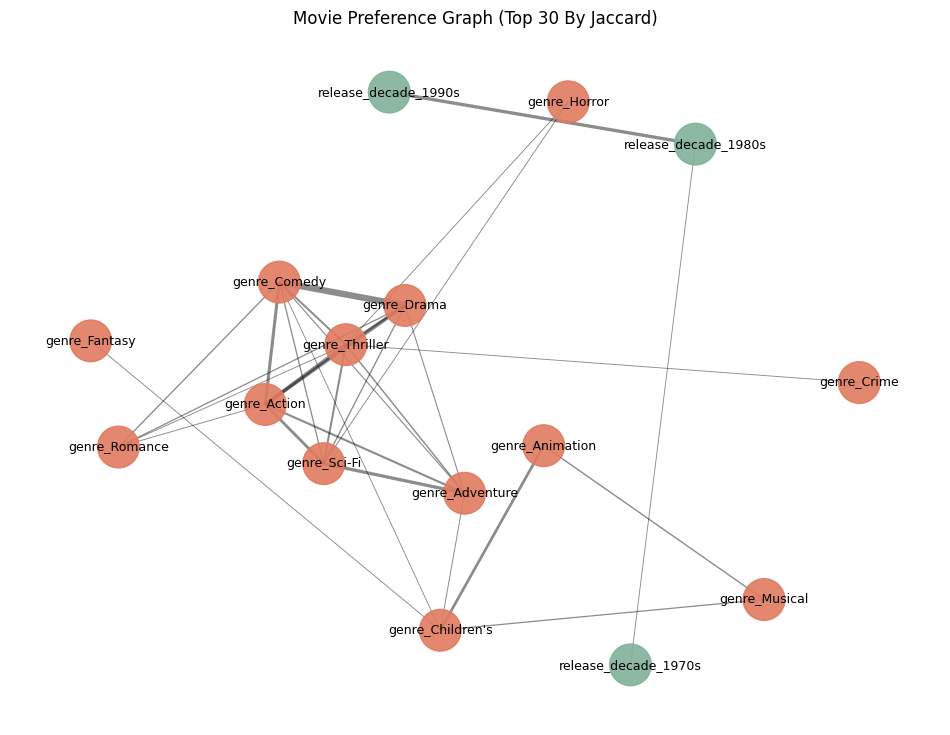

In [16]:
draw_graph(
    extract_top_weight_subgraph(movie_preference_graph, top_n_edges=30),
    title="Movie Preference Graph (Top 30 By Jaccard)",
    figsize=(12, 9),
)

## Interactive Graph Visualization

`plotly` を使って、`all_graph_edges` を `edge_type` ごとに min-max 正規化した `display_weight` で統合可視化する。


In [17]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


## Activation Phase

ここから活性化ベースの伝播と推薦スコアリングを試す。


In [18]:
young_female_persona = {
    "gender_F": 1.0,
    "age_18_24": 1.0,
    "occupation_college_grad_student": 1.0,
}

missing_persona_columns = [
    column for column in young_female_persona
    if column not in user_attribute_columns
]
if missing_persona_columns:
    raise ValueError(f"Persona columns not found: {missing_persona_columns}")

young_female_persona


{'gender_F': 1.0, 'age_18_24': 1.0, 'occupation_college_grad_student': 1.0}

In [19]:
young_female_activation_history = trace_activation(
    graph=combined_attribute_graph,
    seed_activation=young_female_persona,
    iterations=2,
    reinjection_weight=0.25,
    include_seed_nodes=False,
    node_type_filter=None,
    normalize_output=True,
)

young_female_support_activation_history = trace_activation(
    graph=combined_attribute_graph,
    seed_activation=young_female_persona,
    iterations=2,
    reinjection_weight=0.25,
    edge_probability_attr="support_transition_prob",
    include_seed_nodes=False,
    node_type_filter=None,
    normalize_output=True,
)

young_female_movie_activation_history = young_female_activation_history.loc[
    young_female_activation_history["node_group"] == "movie"
].reset_index(drop=True)

young_female_support_movie_activation_history = young_female_support_activation_history.loc[
    young_female_support_activation_history["node_group"] == "movie"
].reset_index(drop=True)

young_female_movie_activation_history_pivot = (
    young_female_movie_activation_history
    .pivot_table(
        index="iteration",
        columns="node_id",
        values="activation",
        fill_value=0.0,
    )
    .sort_index()
)

young_female_support_movie_activation_history_pivot = (
    young_female_support_movie_activation_history
    .pivot_table(
        index="iteration",
        columns="node_id",
        values="activation",
        fill_value=0.0,
    )
    .sort_index()
)

pd.concat(
    {
        "lift": young_female_movie_activation_history_pivot,
        "support": young_female_support_movie_activation_history_pivot,
    },
    names=["score_type", "iteration"],
)


node_id              genre_Action genre_Adventure genre_Animation  \
score_type iteration                                                
lift       1             0.016815        0.013314        0.120521   
           2             0.021031          0.0221        0.050623   
support    1             0.058473        0.031473        0.012826   
           2             0.050067        0.027934        0.010593   

node_id              genre_Children's genre_Comedy genre_Crime  \
score_type iteration                                             
lift       1                   0.1134     0.031949    0.013387   
           2                   0.0709     0.048726    0.003672   
support    1                 0.021326     0.092164    0.018731   
           2                 0.017882     0.060362    0.007367   

node_id              genre_Documentary genre_Drama genre_Fantasy  \
score_type iteration                                               
lift       1                  0.001386    0.017513       0.04957   
           2                   0.00099    0.054645      0.012858   
support    1                  0.001708    0.084494      0.009514   
           2                  0.001904    0.069937      0.004147   

node_id              genre_Film-Noir  ... genre_Western release_decade_1930s  \
score_type iteration                  ...                                      
lift       1                     0.0  ...           0.0             0.022081   
           2                0.000048  ...      0.000048             0.014721   
support    1                0.003469  ...      0.003678             0.002656   
           2                0.000871  ...      0.000803             0.001771   

node_id              release_decade_1940s release_decade_1950s  \
score_type iteration                                             
lift       1                     0.026733             0.015222   
           2                     0.004532             0.002731   
support    1                     0.004318             0.006813   
           2                     0.001089             0.002446   

node_id              release_decade_1960s release_decade_1970s  \
score_type iteration                                             
lift       1                          0.0                  0.0   
           2                     0.000404             0.002364   
support    1                     0.008993             0.014769   
           2                     0.002807             0.008672   

node_id              release_decade_1980s release_decade_1990s  \
score_type iteration                                             
lift       1                          0.0             0.067841   
           2                     0.021241             0.051309   
support    1                     0.047266             0.144671   
           2                     0.038289             0.058956   

node_id              release_decade_2000s release_decade_1920s  
score_type iteration                                            
lift       1                     0.119582                  NaN  
           2                     0.021337                  NaN  
support    1                      0.01195             0.000326  
           2                     0.005739             0.000218  

[4 rows x 27 columns]

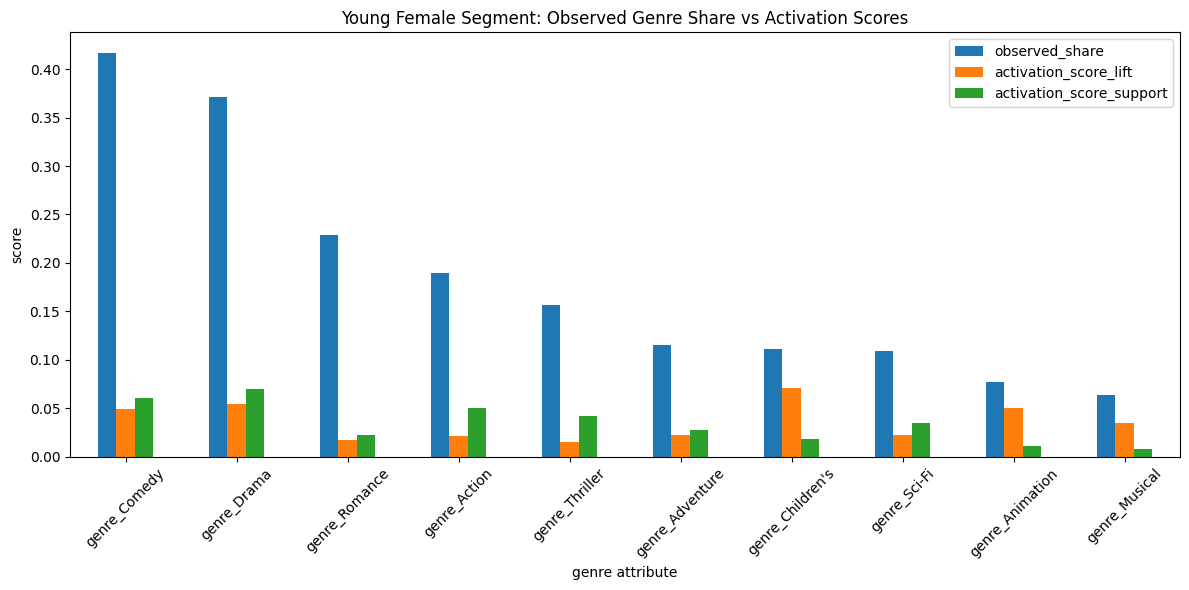

In [20]:
young_female_movie_activation = (
    young_female_movie_activation_history
    .loc[young_female_movie_activation_history["iteration"] == young_female_movie_activation_history["iteration"].max()]
    [["node_id", "activation"]]
    .rename(columns={"activation": "activation_score_lift"})
)

young_female_support_movie_activation = (
    young_female_support_movie_activation_history
    .loc[
        young_female_support_movie_activation_history["iteration"]
        == young_female_support_movie_activation_history["iteration"].max()
    ]
    [["node_id", "activation"]]
    .rename(columns={"activation": "activation_score_support"})
)

young_female_segment_user_ids = users_df.loc[
    (users_df[list(young_female_persona.keys())] == 1).all(axis=1),
    "user_id",
]

young_female_segment_transactions = transaction_df.loc[
    transaction_df["user_id"].isin(young_female_segment_user_ids)
].copy()

young_female_genre_observed_df = (
    young_female_segment_transactions
    .groupby("user_id")[movie_genre_columns]
    .mean()
    .mean()
    .rename_axis("node_id")
    .reset_index(name="observed_share")
)

young_female_genre_interaction_count_df = (
    young_female_segment_transactions[movie_genre_columns]
    .sum()
    .rename_axis("node_id")
    .reset_index(name="interaction_count")
)

young_female_genre_observed_df = young_female_genre_observed_df.merge(
    young_female_genre_interaction_count_df,
    on="node_id",
    how="left",
)

young_female_genre_comparison_df = (
    young_female_genre_observed_df
    .merge(
        young_female_movie_activation.loc[
            young_female_movie_activation["node_id"].isin(movie_genre_columns)
        ],
        on="node_id",
        how="outer",
    )
    .merge(
        young_female_support_movie_activation.loc[
            young_female_support_movie_activation["node_id"].isin(movie_genre_columns)
        ],
        on="node_id",
        how="outer",
    )
    .fillna(
        {
            "observed_share": 0.0,
            "interaction_count": 0.0,
            "activation_score_lift": 0.0,
            "activation_score_support": 0.0,
        }
    )
    .sort_values("observed_share", ascending=False)
    .reset_index(drop=True)
)

young_female_genre_plot_df = young_female_genre_comparison_df.head(10).copy()
plot_df = young_female_genre_plot_df.set_index("node_id")[[
    "observed_share",
    "activation_score_lift",
    "activation_score_support",
]]
plot_df.plot(kind="bar", figsize=(12, 6), rot=45)
plt.title("Young Female Segment: Observed Genre Share vs Activation Scores")
plt.ylabel("score")
plt.xlabel("genre attribute")
plt.tight_layout()
plt.show()
